--- RESULTADOS KNN REGRESSOR ---
Mejor número de vecinos (k): 3
MSE: 3488.19
MAE: 51.78
R^2: -0.01


D:\Jupyter\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(


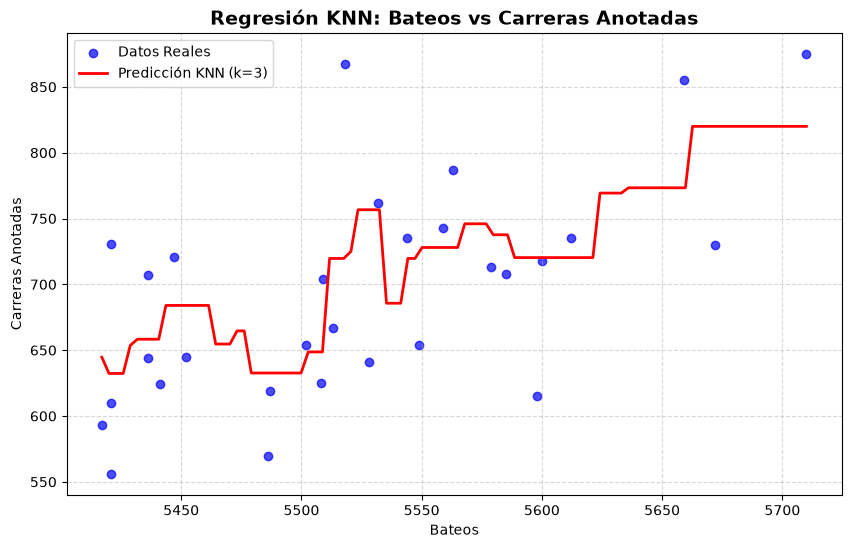

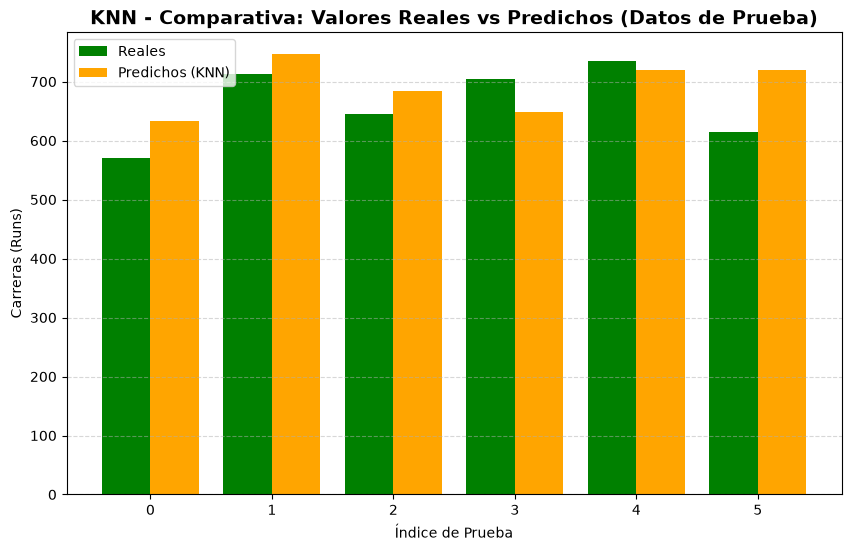

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Cargar y limpiar el dataset
df_beisbol_knn = pd.read_csv('beisbol.csv')
if 'Unnamed: 0' in df_beisbol_knn.columns:
    df_beisbol_knn = df_beisbol_knn.drop(columns=['Unnamed: 0'])

# 2. Definir variables
X_knn = df_beisbol_knn[['bateos']]
y_knn = df_beisbol_knn['runs']

# 3. Dividir los datos (80% entrenamiento, 20% prueba)
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_knn, y_knn, test_size=0.2, random_state=42)

# 4. Búsqueda de Hiperparámetros con GridSearchCV
# Buscamos el mejor número de vecinos (n_neighbors)
parametros_knn = {'n_neighbors': [2, 3, 4, 5, 6, 7]}
knn_base = KNeighborsRegressor()
grid_knn = GridSearchCV(knn_base, parametros_knn, cv=5)
grid_knn.fit(X_train_k, y_train_k)

# 5. Evaluación del modelo óptimo
mejor_knn = grid_knn.best_estimator_
y_pred_k = mejor_knn.predict(X_test_k)

# Calcular métricas
mse_k = mean_squared_error(y_test_k, y_pred_k)
mae_k = mean_absolute_error(y_test_k, y_pred_k)
r2_k = r2_score(y_test_k, y_pred_k)

# 6. Imprimir Resultados
print("--- RESULTADOS KNN REGRESSOR ---")
print(f"Mejor número de vecinos (k): {mejor_knn.n_neighbors}")
print(f"MSE: {mse_k:.2f}")
print(f"MAE: {mae_k:.2f}")
print(f"R^2: {r2_k:.2f}")

# 7. Gráfica 1: Dispersión y línea de predicción de KNN
# Para que la línea de KNN se vea bien, generamos puntos intermedios
X_rango = np.linspace(X_knn.min(), X_knn.max(), 100).reshape(-1, 1)
y_rango_pred = mejor_knn.predict(X_rango)

plt.figure(figsize=(10, 6))
plt.scatter(X_knn, y_knn, color='blue', label='Datos Reales', alpha=0.7)
plt.plot(X_rango, y_rango_pred, color='red', label=f'Predicción KNN (k={mejor_knn.n_neighbors})', linewidth=2)
plt.title('Regresión KNN: Bateos vs Carreras Anotadas', fontsize=14, fontweight='bold')
plt.xlabel('Bateos')
plt.ylabel('Carreras Anotadas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 8. Gráfica 2: Comparativa de Barras (Reales vs Predichos)
plt.figure(figsize=(10, 6))
x_ax_k = np.arange(len(y_test_k))
plt.bar(x_ax_k - 0.2, y_test_k, width=0.4, label='Reales', color='green')
plt.bar(x_ax_k + 0.2, y_pred_k, width=0.4, label='Predichos (KNN)', color='orange')
plt.title('KNN - Comparativa: Valores Reales vs Predichos (Datos de Prueba)', fontsize=14, fontweight='bold')
plt.xlabel('Índice de Prueba')
plt.ylabel('Carreras (Runs)')
plt.xticks(x_ax_k)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()